# Task 3: Model Explainability using SHAP

This notebook implements comprehensive model explainability using SHAP (SHapley Additive exPlanations) to interpret fraud detection model decisions.

## Objectives
1. **Feature Importance Baseline**: Extract built-in feature importance from ensemble models
2. **SHAP Analysis**: Generate SHAP summary plots and force plots for individual predictions
3. **Interpretation**: Compare SHAP with built-in importance and identify top fraud drivers
4. **Business Recommendations**: Provide actionable insights based on SHAP analysis


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import warnings
from pathlib import Path
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')

# Set up paths
project_root = Path().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
elif (project_root / 'notebooks').exists():
    pass
else:
    current = Path().resolve()
    while current != current.parent:
        if (current / 'data').exists():
            project_root = current
            break
        current = current.parent

DATA_DIR = project_root / 'data' / 'processed'
MODELS_DIR = project_root / 'models'
OUTPUT_DIR = project_root / 'outputs' / 'eda' / 'shap'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Initialize SHAP
shap.initjs()

print("✓ Libraries imported successfully!")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


✓ Libraries imported successfully!
Data directory: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/data/processed
Models directory: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/models
Output directory: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/shap


## 1. Load Data and Best Models


In [2]:
# Load processed test data
print("Loading test data...")
X_test_fraud = pd.read_csv(DATA_DIR / 'fraud_test_features.csv')
y_test_fraud = pd.read_csv(DATA_DIR / 'fraud_test_target.csv')['class']
X_test_cc = pd.read_csv(DATA_DIR / 'creditcard_test_features.csv')
y_test_cc = pd.read_csv(DATA_DIR / 'creditcard_test_target.csv')['Class']

print(f"E-commerce test data: {X_test_fraud.shape}")
print(f"Credit card test data: {X_test_cc.shape}")

# Load best models (assuming Random Forest or XGBoost were selected)
print("\nLoading best models...")
try:
    rf_fraud = pickle.load(open(MODELS_DIR / 'rf_fraud_best.pkl', 'rb'))
    print("✓ Loaded Random Forest (E-commerce)")
    best_model_fraud = rf_fraud
    best_model_fraud_name = "Random Forest"
except:
    try:
        xgb_fraud = pickle.load(open(MODELS_DIR / 'xgb_fraud_best.pkl', 'rb'))
        print("✓ Loaded XGBoost (E-commerce)")
        best_model_fraud = xgb_fraud
        best_model_fraud_name = "XGBoost"
    except:
        lr_fraud = pickle.load(open(MODELS_DIR / 'lr_fraud_baseline.pkl', 'rb'))
        print("✓ Loaded Logistic Regression (E-commerce)")
        best_model_fraud = lr_fraud
        best_model_fraud_name = "Logistic Regression"

try:
    rf_cc = pickle.load(open(MODELS_DIR / 'rf_cc_best.pkl', 'rb'))
    print("✓ Loaded Random Forest (Credit Card)")
    best_model_cc = rf_cc
    best_model_cc_name = "Random Forest"
except:
    try:
        xgb_cc = pickle.load(open(MODELS_DIR / 'xgb_cc_best.pkl', 'rb'))
        print("✓ Loaded XGBoost (Credit Card)")
        best_model_cc = xgb_cc
        best_model_cc_name = "XGBoost"
    except:
        lr_cc = pickle.load(open(MODELS_DIR / 'lr_cc_baseline.pkl', 'rb'))
        print("✓ Loaded Logistic Regression (Credit Card)")
        best_model_cc = lr_cc
        best_model_cc_name = "Logistic Regression"


Loading test data...
E-commerce test data: (30223, 19)
Credit card test data: (56962, 30)

Loading best models...
✓ Loaded XGBoost (E-commerce)
✓ Loaded Logistic Regression (Credit Card)


### 2.1 E-commerce Fraud Data - Feature Importance


Top 10 Most Important Features (E-commerce):
              feature  importance
4   time_since_signup    0.293688
3         day_of_week    0.153241
12      source_Direct    0.076420
2         hour_of_day    0.071907
18              sex_M    0.067053
17     browser_Safari    0.065134
14    browser_FireFox    0.060944
16      browser_Opera    0.060479
15         browser_IE    0.057793
13         source_SEO    0.043862

✓ Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/shap/fraud_feature_importance_top10.png


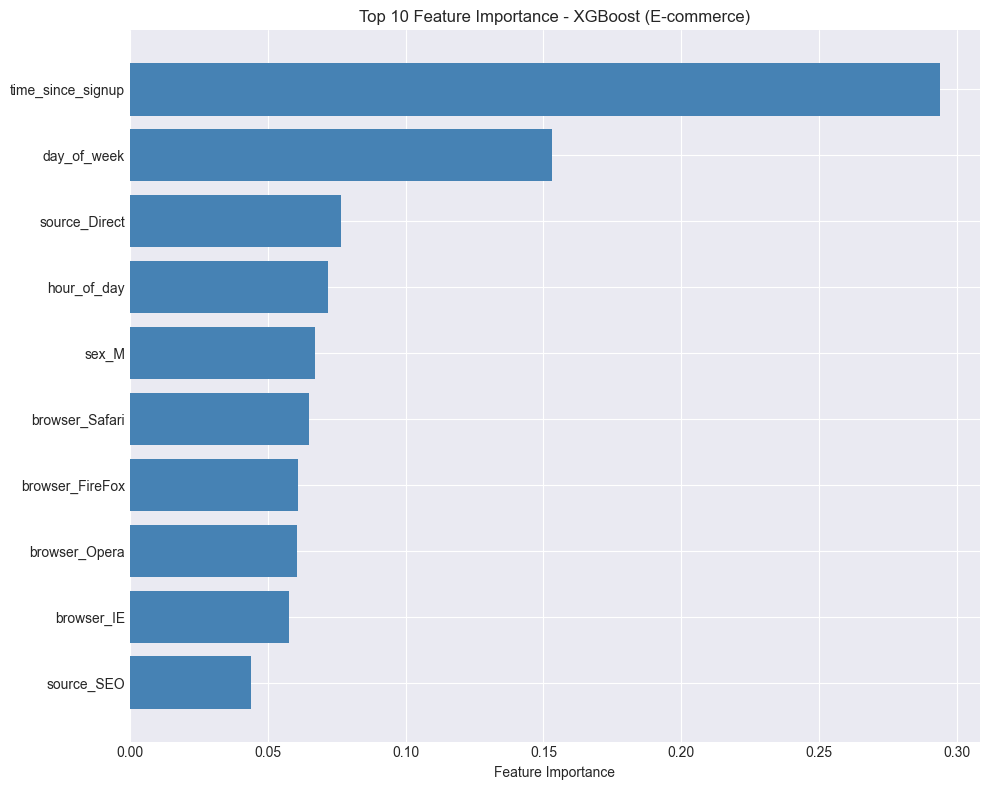

In [3]:
# Extract feature importance for e-commerce model
if hasattr(best_model_fraud, 'feature_importances_'):
    feature_importance_fraud = pd.DataFrame({
        'feature': X_test_fraud.columns,
        'importance': best_model_fraud.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("Top 10 Most Important Features (E-commerce):")
    print(feature_importance_fraud.head(10))
    
    # Visualize top 10 features
    fig, ax = plt.subplots(figsize=(10, 8))
    top_10 = feature_importance_fraud.head(10)
    ax.barh(range(len(top_10)), top_10['importance'].values, color='steelblue')
    ax.set_yticks(range(len(top_10)))
    ax.set_yticklabels(top_10['feature'])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 10 Feature Importance - {best_model_fraud_name} (E-commerce)')
    ax.invert_yaxis()
    plt.tight_layout()
    
    # Save plot
    filepath = OUTPUT_DIR / 'fraud_feature_importance_top10.png'
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"\n✓ Plot saved to: {filepath}")
    plt.show()
    
    built_in_importance_fraud = feature_importance_fraud
else:
    print("⚠ Model does not have feature_importances_ attribute (likely Logistic Regression)")
    print("   Will use SHAP importance instead.")
    built_in_importance_fraud = None


### 2.2 Credit Card Fraud Data - Feature Importance


In [4]:
# Extract feature importance for credit card model
if hasattr(best_model_cc, 'feature_importances_'):
    feature_importance_cc = pd.DataFrame({
        'feature': X_test_cc.columns,
        'importance': best_model_cc.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("Top 10 Most Important Features (Credit Card):")
    print(feature_importance_cc.head(10))
    
    # Visualize top 10 features
    fig, ax = plt.subplots(figsize=(10, 8))
    top_10 = feature_importance_cc.head(10)
    ax.barh(range(len(top_10)), top_10['importance'].values, color='coral')
    ax.set_yticks(range(len(top_10)))
    ax.set_yticklabels(top_10['feature'])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 10 Feature Importance - {best_model_cc_name} (Credit Card)')
    ax.invert_yaxis()
    plt.tight_layout()
    
    # Save plot
    filepath = OUTPUT_DIR / 'creditcard_feature_importance_top10.png'
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"\n✓ Plot saved to: {filepath}")
    plt.show()
    
    built_in_importance_cc = feature_importance_cc
else:
    print("⚠ Model does not have feature_importances_ attribute (likely Logistic Regression)")
    print("   Will use SHAP importance instead.")
    built_in_importance_cc = None


⚠ Model does not have feature_importances_ attribute (likely Logistic Regression)
   Will use SHAP importance instead.


## 3. SHAP Analysis

Generate SHAP values and visualizations for model explainability.


### 3.1 E-commerce Fraud Data - SHAP Analysis


In [5]:
# Create SHAP explainer for e-commerce model
print("Creating SHAP explainer for E-commerce model...")
print("This may take a few minutes...")

# Use a sample of data for faster computation (SHAP can be slow on large datasets)
sample_size = min(1000, len(X_test_fraud))
X_sample_fraud = X_test_fraud.sample(n=sample_size, random_state=42)
y_sample_fraud = y_test_fraud.loc[X_sample_fraud.index]

# Choose appropriate explainer based on model type
if best_model_fraud_name in ['Random Forest', 'XGBoost']:
    explainer_fraud = shap.TreeExplainer(best_model_fraud)
    shap_values_fraud = explainer_fraud.shap_values(X_sample_fraud)
    
    # For binary classification, get SHAP values for the positive class (fraud)
    if isinstance(shap_values_fraud, list):
        shap_values_fraud = shap_values_fraud[1]  # Use fraud class (index 1)
else:
    # For linear models, use KernelExplainer or LinearExplainer
    explainer_fraud = shap.LinearExplainer(best_model_fraud, X_sample_fraud)
    shap_values_fraud = explainer_fraud.shap_values(X_sample_fraud)

print(f"✓ SHAP values computed for {sample_size} samples")
print(f"SHAP values shape: {shap_values_fraud.shape}")


Creating SHAP explainer for E-commerce model...
This may take a few minutes...
✓ SHAP values computed for 1000 samples
SHAP values shape: (1000, 19)


Generating SHAP Summary Plot...
✓ Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/shap/fraud_shap_summary_plot.png


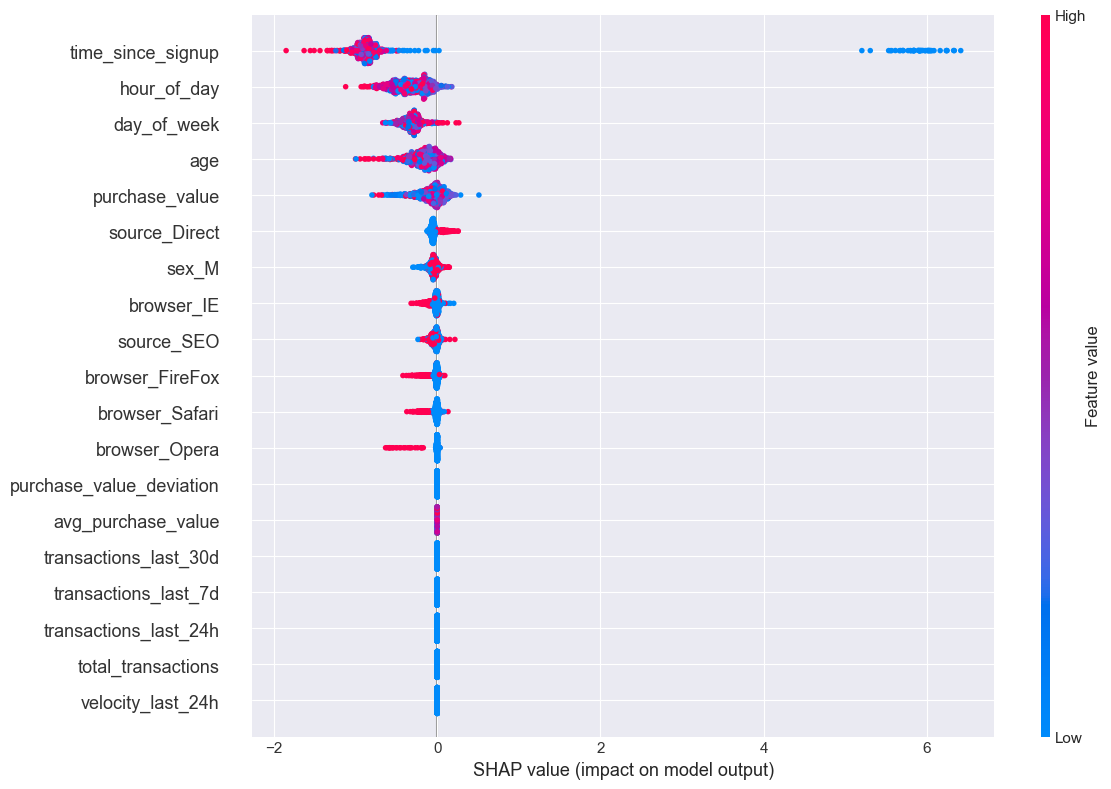

✓ Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/shap/fraud_shap_summary_bar.png


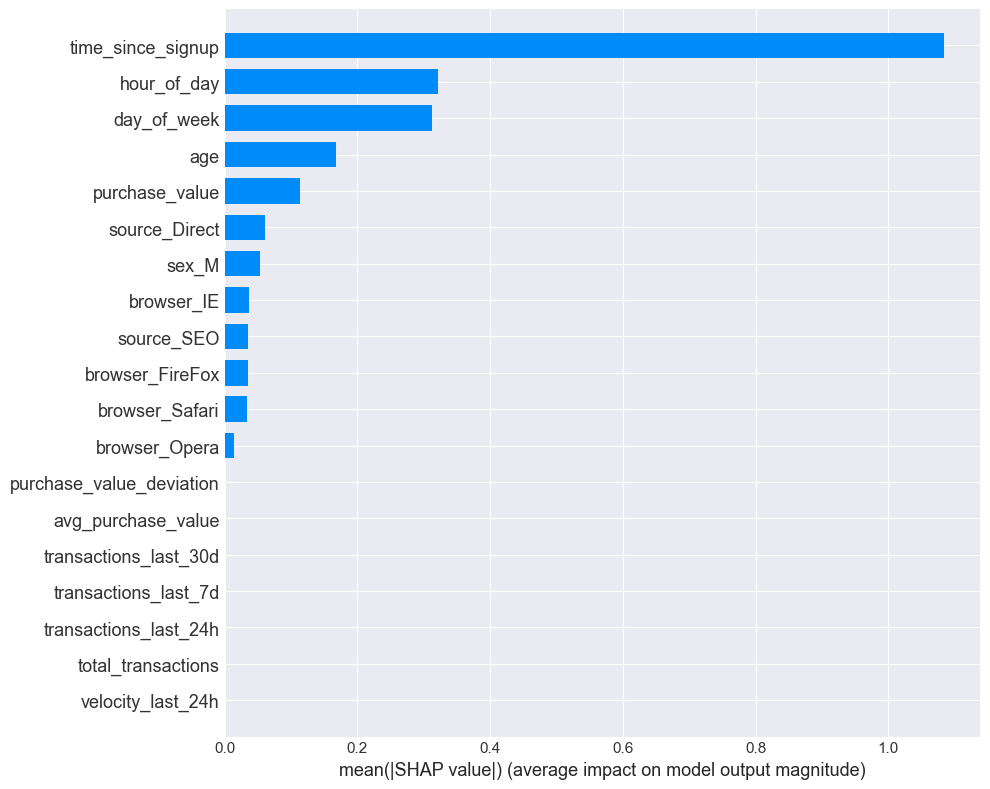

In [6]:
# SHAP Summary Plot (Global Feature Importance)
print("Generating SHAP Summary Plot...")
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_fraud, X_sample_fraud, show=False, plot_size=(12, 8))
plt.tight_layout()

# Save plot
filepath = OUTPUT_DIR / 'fraud_shap_summary_plot.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"✓ Plot saved to: {filepath}")
plt.show()

# SHAP Summary Plot (Bar plot - mean absolute SHAP values)
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_fraud, X_sample_fraud, plot_type="bar", show=False, plot_size=(10, 8))
plt.tight_layout()

filepath = OUTPUT_DIR / 'fraud_shap_summary_bar.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"✓ Plot saved to: {filepath}")
plt.show()


In [8]:
# Get predictions to identify TP, FP, FN cases
y_pred_fraud = best_model_fraud.predict(X_sample_fraud)
y_pred_proba_fraud = best_model_fraud.predict_proba(X_sample_fraud)[:, 1]

# Identify cases
true_positives = (y_sample_fraud == 1) & (y_pred_fraud == 1)
false_positives = (y_sample_fraud == 0) & (y_pred_fraud == 1)
false_negatives = (y_sample_fraud == 1) & (y_pred_fraud == 0)

print("Case Identification:")
print(f"True Positives: {true_positives.sum()}")
print(f"False Positives: {false_positives.sum()}")
print(f"False Negatives: {false_negatives.sum()}")

# Select examples
tp_idx = X_sample_fraud[true_positives].index[0] if true_positives.sum() > 0 else None
fp_idx = X_sample_fraud[false_positives].index[0] if false_positives.sum() > 0 else None
fn_idx = X_sample_fraud[false_negatives].index[0] if false_negatives.sum() > 0 else None

print(f"\nSelected examples:")
print(f"True Positive index: {tp_idx}")
print(f"False Positive index: {fp_idx}")
print(f"False Negative index: {fn_idx}")


Case Identification:
True Positives: 39
False Positives: 4
False Negatives: 40

Selected examples:
True Positive index: 19409
False Positive index: 26219
False Negative index: 21708



Generating SHAP Force Plots...

1. True Positive (Correctly Identified Fraud) - Index 19409
   Actual: Fraud, Predicted: Fraud, Probability: 0.9933
   ✓ Saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/shap/fraud_shap_force_tp.png


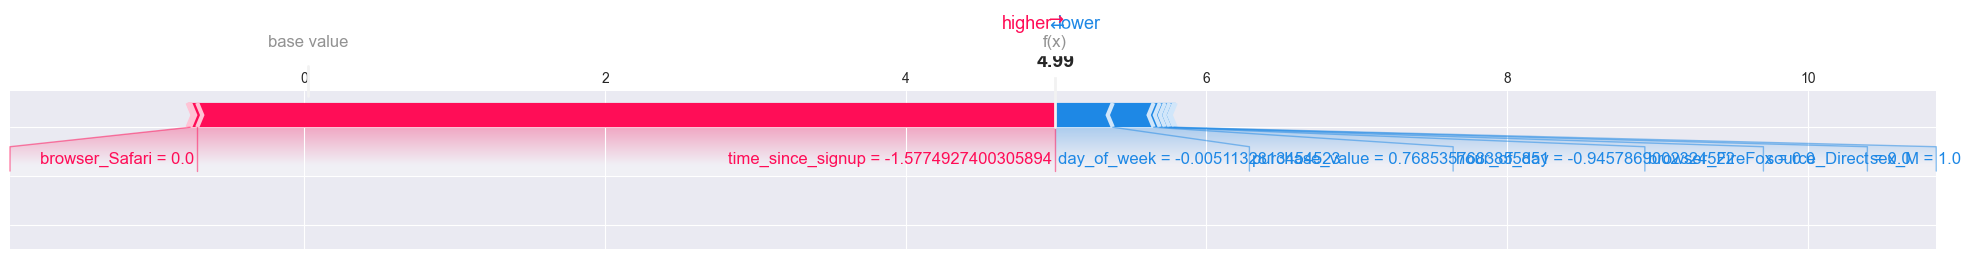


2. False Positive (Legitimate Flagged as Fraud) - Index 26219
   Actual: Non-Fraud, Predicted: Fraud, Probability: 0.9800
   ✓ Saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/shap/fraud_shap_force_fp.png


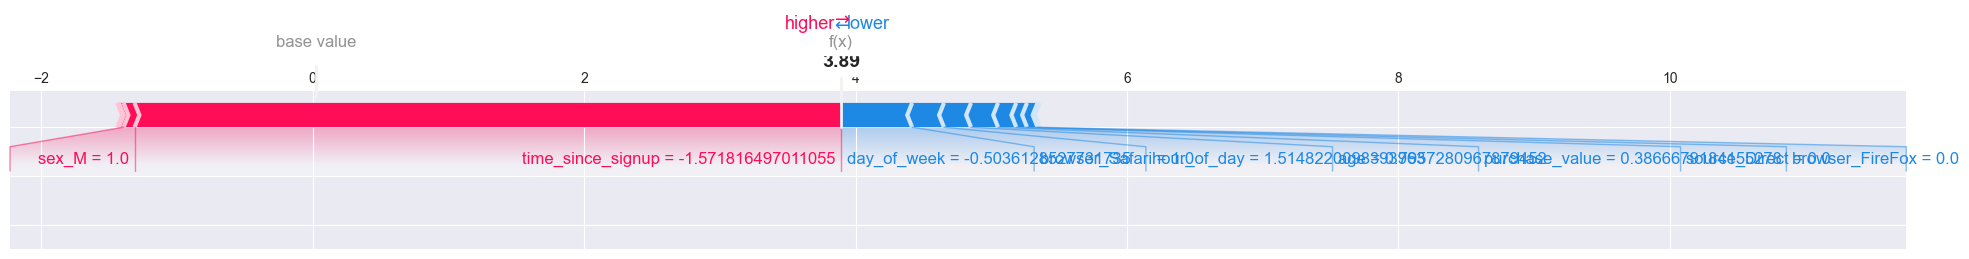


3. False Negative (Missed Fraud) - Index 21708
   Actual: Fraud, Predicted: Non-Fraud, Probability: 0.1733
   ✓ Saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/shap/fraud_shap_force_fn.png


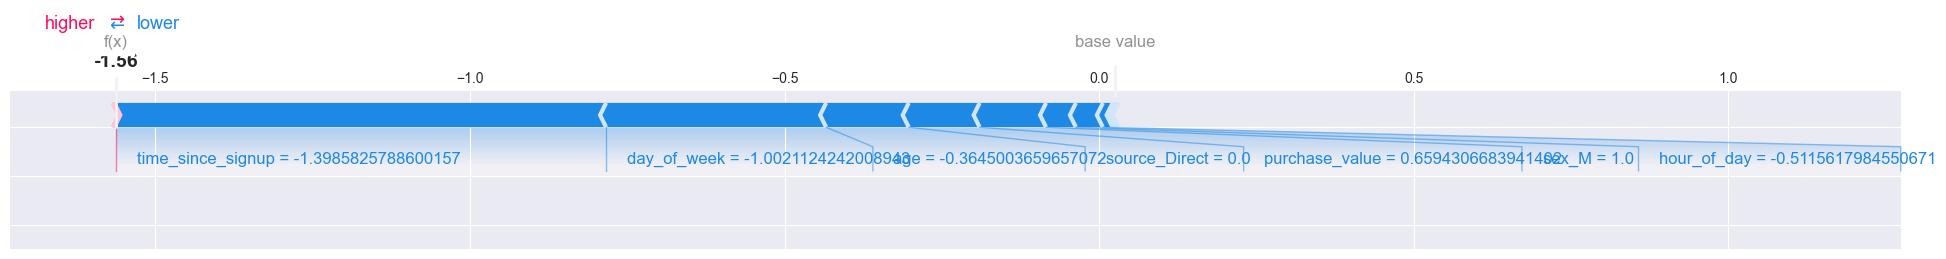

In [9]:
# SHAP Force Plots for individual predictions
print("\nGenerating SHAP Force Plots...")

# Find indices in the sample
if tp_idx is not None:
    tp_sample_idx = X_sample_fraud.index.get_loc(tp_idx)
    print(f"\n1. True Positive (Correctly Identified Fraud) - Index {tp_idx}")
    print(f"   Actual: Fraud, Predicted: Fraud, Probability: {y_pred_proba_fraud[tp_sample_idx]:.4f}")
    
    # Force plot
    shap.force_plot(
        explainer_fraud.expected_value[1] if isinstance(explainer_fraud.expected_value, (list, np.ndarray)) else explainer_fraud.expected_value,
        shap_values_fraud[tp_sample_idx],
        X_sample_fraud.iloc[tp_sample_idx],
        matplotlib=True,
        show=False
    )
    plt.tight_layout()
    filepath = OUTPUT_DIR / 'fraud_shap_force_tp.png'
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved to: {filepath}")
    plt.show()

if fp_idx is not None:
    fp_sample_idx = X_sample_fraud.index.get_loc(fp_idx)
    print(f"\n2. False Positive (Legitimate Flagged as Fraud) - Index {fp_idx}")
    print(f"   Actual: Non-Fraud, Predicted: Fraud, Probability: {y_pred_proba_fraud[fp_sample_idx]:.4f}")
    
    shap.force_plot(
        explainer_fraud.expected_value[1] if isinstance(explainer_fraud.expected_value, (list, np.ndarray)) else explainer_fraud.expected_value,
        shap_values_fraud[fp_sample_idx],
        X_sample_fraud.iloc[fp_sample_idx],
        matplotlib=True,
        show=False
    )
    plt.tight_layout()
    filepath = OUTPUT_DIR / 'fraud_shap_force_fp.png'
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved to: {filepath}")
    plt.show()

if fn_idx is not None:
    fn_sample_idx = X_sample_fraud.index.get_loc(fn_idx)
    print(f"\n3. False Negative (Missed Fraud) - Index {fn_idx}")
    print(f"   Actual: Fraud, Predicted: Non-Fraud, Probability: {y_pred_proba_fraud[fn_sample_idx]:.4f}")
    
    shap.force_plot(
        explainer_fraud.expected_value[1] if isinstance(explainer_fraud.expected_value, (list, np.ndarray)) else explainer_fraud.expected_value,
        shap_values_fraud[fn_sample_idx],
        X_sample_fraud.iloc[fn_sample_idx],
        matplotlib=True,
        show=False
    )
    plt.tight_layout()
    filepath = OUTPUT_DIR / 'fraud_shap_force_fn.png'
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved to: {filepath}")
    plt.show()
else:
    print("\n⚠ No False Negatives found in sample. This is good but limits analysis.")


In [10]:
# Create SHAP explainer for credit card model
print("Creating SHAP explainer for Credit Card model...")
print("This may take a few minutes...")

# Use a sample for faster computation
sample_size_cc = min(1000, len(X_test_cc))
X_sample_cc = X_test_cc.sample(n=sample_size_cc, random_state=42)
y_sample_cc = y_test_cc.loc[X_sample_cc.index]

# Choose appropriate explainer
if best_model_cc_name in ['Random Forest', 'XGBoost']:
    explainer_cc = shap.TreeExplainer(best_model_cc)
    shap_values_cc = explainer_cc.shap_values(X_sample_cc)
    
    if isinstance(shap_values_cc, list):
        shap_values_cc = shap_values_cc[1]  # Use fraud class
else:
    explainer_cc = shap.LinearExplainer(best_model_cc, X_sample_cc)
    shap_values_cc = explainer_cc.shap_values(X_sample_cc)

print(f"✓ SHAP values computed for {sample_size_cc} samples")
print(f"SHAP values shape: {shap_values_cc.shape}")


Creating SHAP explainer for Credit Card model...
This may take a few minutes...
✓ SHAP values computed for 1000 samples
SHAP values shape: (1000, 30)


Generating SHAP Summary Plot...
✓ Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/shap/creditcard_shap_summary_plot.png


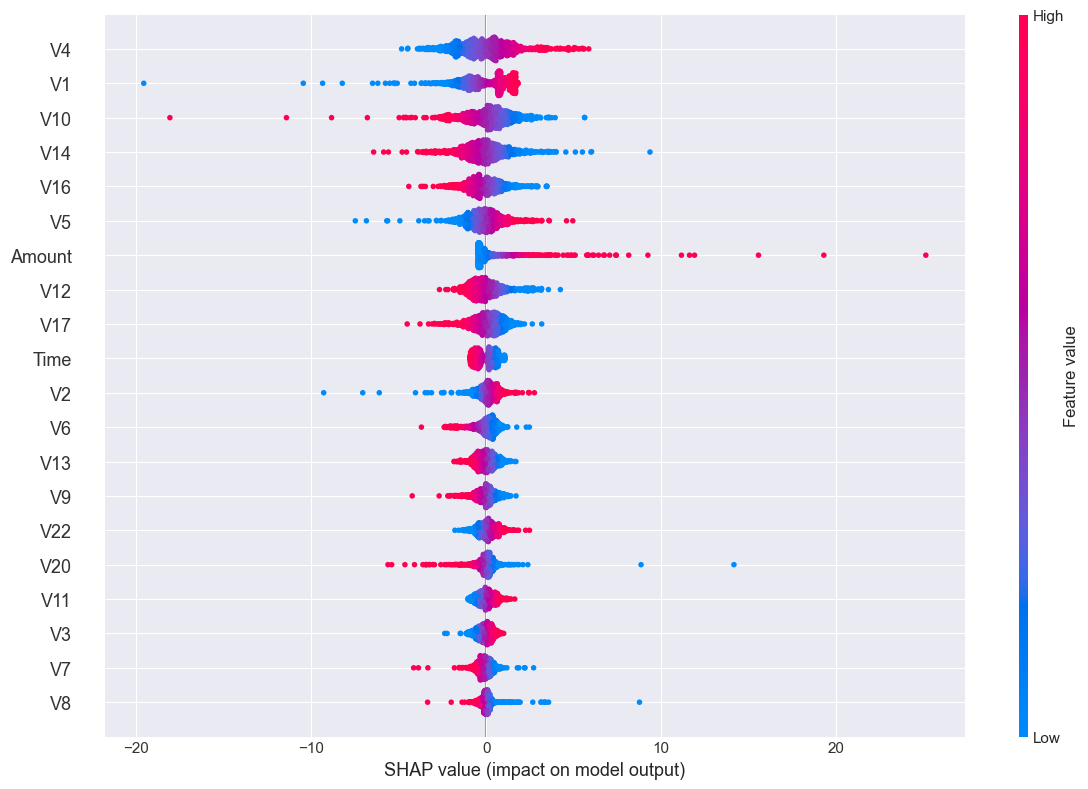

✓ Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/shap/creditcard_shap_summary_bar.png


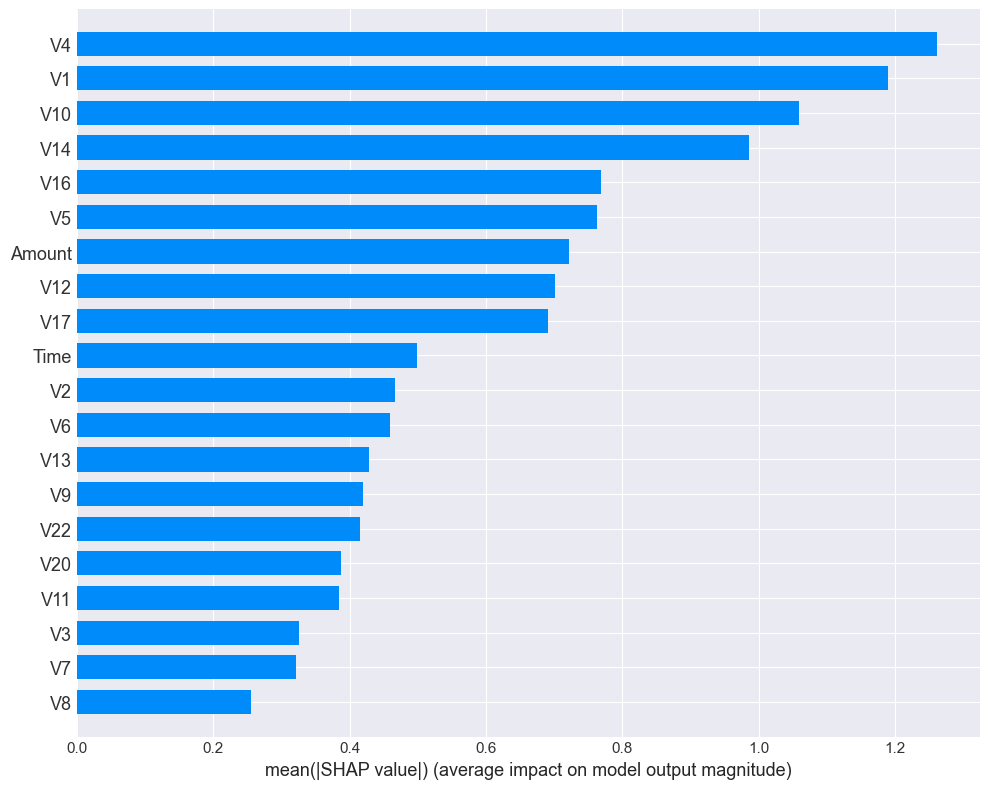

In [11]:
# SHAP Summary Plot for Credit Card
print("Generating SHAP Summary Plot...")
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_cc, X_sample_cc, show=False, plot_size=(12, 8))
plt.tight_layout()

filepath = OUTPUT_DIR / 'creditcard_shap_summary_plot.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"✓ Plot saved to: {filepath}")
plt.show()

# Bar plot
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_cc, X_sample_cc, plot_type="bar", show=False, plot_size=(10, 8))
plt.tight_layout()

filepath = OUTPUT_DIR / 'creditcard_shap_summary_bar.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"✓ Plot saved to: {filepath}")
plt.show()


In [14]:
# Get predictions and identify cases for Credit Card
y_pred_cc = best_model_cc.predict(X_sample_cc)
y_pred_proba_cc = best_model_cc.predict_proba(X_sample_cc)[:, 1]

true_positives_cc = (y_sample_cc == 1) & (y_pred_cc == 1)
false_positives_cc = (y_sample_cc == 0) & (y_pred_cc == 1)
false_negatives_cc = (y_sample_cc == 1) & (y_pred_cc == 0)

print("Case Identification (Credit Card):")
print(f"True Positives: {true_positives_cc.sum()}")
print(f"False Positives: {false_positives_cc.sum()}")
print(f"False Negatives: {false_negatives_cc.sum()}")

tp_idx_cc = X_sample_cc[true_positives_cc].index[0] if true_positives_cc.sum() > 0 else None
fp_idx_cc = X_sample_cc[false_positives_cc].index[0] if false_positives_cc.sum() > 0 else None
fn_idx_cc = X_sample_cc[false_negatives_cc].index[0] if false_negatives_cc.sum() > 0 else None


Case Identification (Credit Card):
True Positives: 0
False Positives: 26
False Negatives: 0



Generating SHAP Force Plots (Credit Card)...

2. False Positive - Index 462
   ✓ Saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/shap/creditcard_shap_force_fp.png


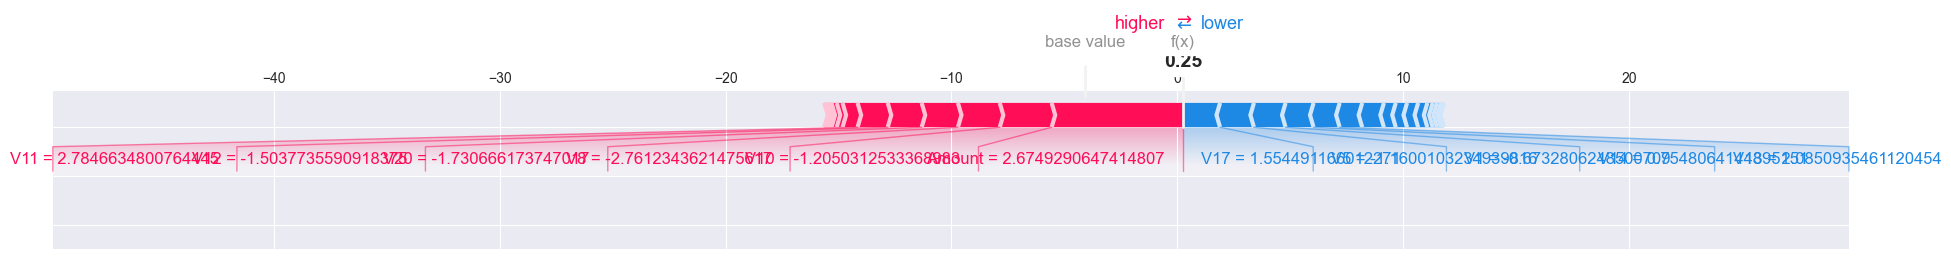

In [15]:
# SHAP Force Plots for Credit Card
print("\nGenerating SHAP Force Plots (Credit Card)...")

if tp_idx_cc is not None:
    tp_sample_idx_cc = X_sample_cc.index.get_loc(tp_idx_cc)
    print(f"\n1. True Positive - Index {tp_idx_cc}")
    
    shap.force_plot(
        explainer_cc.expected_value[1] if isinstance(explainer_cc.expected_value, (list, np.ndarray)) else explainer_cc.expected_value,
        shap_values_cc[tp_sample_idx_cc],
        X_sample_cc.iloc[tp_sample_idx_cc],
        matplotlib=True,
        show=False
    )
    plt.tight_layout()
    filepath = OUTPUT_DIR / 'creditcard_shap_force_tp.png'
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved to: {filepath}")
    plt.show()

if fp_idx_cc is not None:
    fp_sample_idx_cc = X_sample_cc.index.get_loc(fp_idx_cc)
    print(f"\n2. False Positive - Index {fp_idx_cc}")
    
    shap.force_plot(
        explainer_cc.expected_value[1] if isinstance(explainer_cc.expected_value, (list, np.ndarray)) else explainer_cc.expected_value,
        shap_values_cc[fp_sample_idx_cc],
        X_sample_cc.iloc[fp_sample_idx_cc],
        matplotlib=True,
        show=False
    )
    plt.tight_layout()
    filepath = OUTPUT_DIR / 'creditcard_shap_force_fp.png'
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved to: {filepath}")
    plt.show()

if fn_idx_cc is not None:
    fn_sample_idx_cc = X_sample_cc.index.get_loc(fn_idx_cc)
    print(f"\n3. False Negative - Index {fn_idx_cc}")
    
    shap.force_plot(
        explainer_cc.expected_value[1] if isinstance(explainer_cc.expected_value, (list, np.ndarray)) else explainer_cc.expected_value,
        shap_values_cc[fn_sample_idx_cc],
        X_sample_cc.iloc[fn_sample_idx_cc],
        matplotlib=True,
        show=False
    )
    plt.tight_layout()
    filepath = OUTPUT_DIR / 'creditcard_shap_force_fn.png'
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved to: {filepath}")
    plt.show()


SHAP Feature Importance vs Built-in Importance (E-commerce)

Top 10 Features by SHAP Importance:
              feature  shap_importance
4   time_since_signup         1.084058
2         hour_of_day         0.321263
3         day_of_week         0.312483
1                 age         0.168337
0      purchase_value         0.112970
12      source_Direct         0.060124
18              sex_M         0.053115
15         browser_IE         0.036921
13         source_SEO         0.035554
14    browser_FireFox         0.034960

Top 10 Features by Built-in Importance:
              feature  importance
4   time_since_signup    0.293688
3         day_of_week    0.153241
12      source_Direct    0.076420
2         hour_of_day    0.071907
18              sex_M    0.067053
17     browser_Safari    0.065134
14    browser_FireFox    0.060944
16      browser_Opera    0.060479
15         browser_IE    0.057793
13         source_SEO    0.043862

Comparison (Top 10 by SHAP):
             feature  shap_im

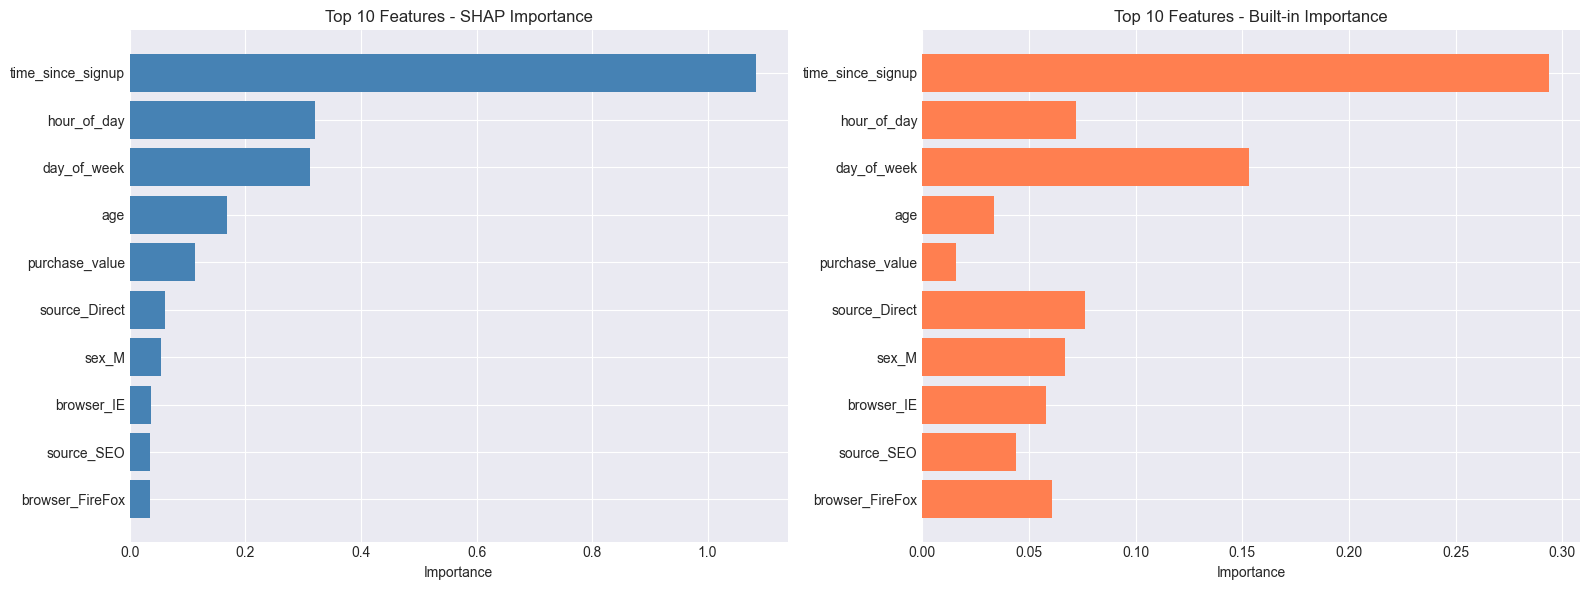

In [16]:
# Calculate SHAP feature importance (mean absolute SHAP values)
shap_importance_fraud = pd.DataFrame({
    'feature': X_sample_fraud.columns,
    'shap_importance': np.abs(shap_values_fraud).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

print("="*80)
print("SHAP Feature Importance vs Built-in Importance (E-commerce)")
print("="*80)
print("\nTop 10 Features by SHAP Importance:")
print(shap_importance_fraud.head(10))

# Compare with built-in importance if available
if built_in_importance_fraud is not None:
    print("\nTop 10 Features by Built-in Importance:")
    print(built_in_importance_fraud.head(10))
    
    # Merge for comparison
    comparison_fraud = shap_importance_fraud.merge(
        built_in_importance_fraud[['feature', 'importance']],
        on='feature',
        how='inner'
    )
    comparison_fraud.columns = ['feature', 'shap_importance', 'built_in_importance']
    comparison_fraud = comparison_fraud.sort_values('shap_importance', ascending=False)
    
    print("\nComparison (Top 10 by SHAP):")
    print(comparison_fraud.head(10))
    
    # Visualize comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    top_10_shap = comparison_fraud.head(10)
    axes[0].barh(range(len(top_10_shap)), top_10_shap['shap_importance'].values, color='steelblue', label='SHAP')
    axes[0].set_yticks(range(len(top_10_shap)))
    axes[0].set_yticklabels(top_10_shap['feature'])
    axes[0].set_xlabel('Importance')
    axes[0].set_title('Top 10 Features - SHAP Importance')
    axes[0].invert_yaxis()
    
    axes[1].barh(range(len(top_10_shap)), top_10_shap['built_in_importance'].values, color='coral', label='Built-in')
    axes[1].set_yticks(range(len(top_10_shap)))
    axes[1].set_yticklabels(top_10_shap['feature'])
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Top 10 Features - Built-in Importance')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    filepath = OUTPUT_DIR / 'fraud_importance_comparison.png'
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"\n✓ Comparison plot saved to: {filepath}")
    plt.show()
else:
    print("\n⚠ Built-in importance not available (model is Logistic Regression)")
    print("   Using SHAP importance only.")


In [17]:
# SHAP importance for Credit Card
shap_importance_cc = pd.DataFrame({
    'feature': X_sample_cc.columns,
    'shap_importance': np.abs(shap_values_cc).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

print("="*80)
print("SHAP Feature Importance vs Built-in Importance (Credit Card)")
print("="*80)
print("\nTop 10 Features by SHAP Importance:")
print(shap_importance_cc.head(10))

if built_in_importance_cc is not None:
    print("\nTop 10 Features by Built-in Importance:")
    print(built_in_importance_cc.head(10))
    
    comparison_cc = shap_importance_cc.merge(
        built_in_importance_cc[['feature', 'importance']],
        on='feature',
        how='inner'
    )
    comparison_cc.columns = ['feature', 'shap_importance', 'built_in_importance']
    comparison_cc = comparison_cc.sort_values('shap_importance', ascending=False)
    
    print("\nComparison (Top 10 by SHAP):")
    print(comparison_cc.head(10))
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    top_10_shap_cc = comparison_cc.head(10)
    axes[0].barh(range(len(top_10_shap_cc)), top_10_shap_cc['shap_importance'].values, color='steelblue')
    axes[0].set_yticks(range(len(top_10_shap_cc)))
    axes[0].set_yticklabels(top_10_shap_cc['feature'])
    axes[0].set_xlabel('Importance')
    axes[0].set_title('Top 10 Features - SHAP Importance (Credit Card)')
    axes[0].invert_yaxis()
    
    axes[1].barh(range(len(top_10_shap_cc)), top_10_shap_cc['built_in_importance'].values, color='coral')
    axes[1].set_yticks(range(len(top_10_shap_cc)))
    axes[1].set_yticklabels(top_10_shap_cc['feature'])
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Top 10 Features - Built-in Importance (Credit Card)')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    filepath = OUTPUT_DIR / 'creditcard_importance_comparison.png'
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"\n✓ Comparison plot saved to: {filepath}")
    plt.show()
else:
    print("\n⚠ Built-in importance not available")


SHAP Feature Importance vs Built-in Importance (Credit Card)

Top 10 Features by SHAP Importance:
   feature  shap_importance
4       V4         1.261272
1       V1         1.188848
10     V10         1.058214
14     V14         0.985532
16     V16         0.769280
5       V5         0.763083
29  Amount         0.722344
12     V12         0.701621
17     V17         0.691569
0     Time         0.498760

⚠ Built-in importance not available


## 5. Top 5 Drivers of Fraud Predictions

Identify and analyze the top 5 features that drive fraud predictions.


TOP 5 DRIVERS OF FRAUD PREDICTIONS - E-commerce Data

Top 5 Features Driving Fraud Predictions:

5. time_since_signup
   SHAP Importance: 1.0841
   Mean value (Fraud cases): -0.7677
   Mean value (Non-Fraud cases): 0.1160
   Difference: -0.8837

3. hour_of_day
   SHAP Importance: 0.3213
   Mean value (Fraud cases): -0.0242
   Mean value (Non-Fraud cases): 0.0111
   Difference: -0.0353

4. day_of_week
   SHAP Importance: 0.3125
   Mean value (Fraud cases): 0.0012
   Mean value (Non-Fraud cases): -0.0046
   Difference: 0.0058

2. age
   SHAP Importance: 0.1683
   Mean value (Fraud cases): 0.1833
   Mean value (Non-Fraud cases): -0.0218
   Difference: 0.2052

1. purchase_value
   SHAP Importance: 0.1130
   Mean value (Fraud cases): 0.0241
   Mean value (Non-Fraud cases): -0.0355
   Difference: 0.0596

✓ Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/shap/fraud_top5_drivers.png


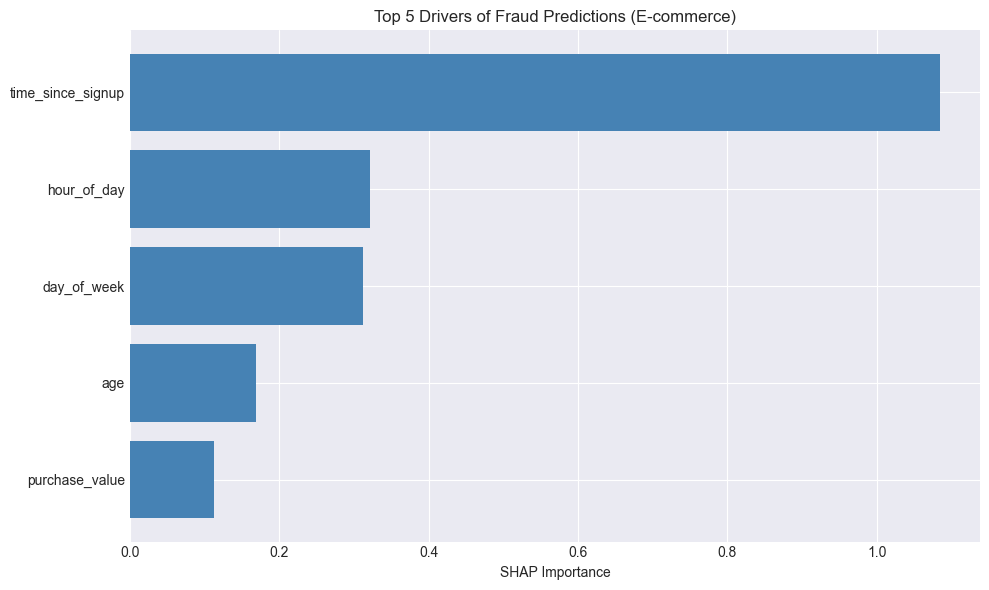

In [19]:
# Top 5 drivers for E-commerce
print("="*80)
print("TOP 5 DRIVERS OF FRAUD PREDICTIONS - E-commerce Data")
print("="*80)

top_5_fraud = shap_importance_fraud.head(5)
print("\nTop 5 Features Driving Fraud Predictions:")
for idx, row in top_5_fraud.iterrows():
    print(f"\n{row.name + 1}. {row['feature']}")
    print(f"   SHAP Importance: {row['shap_importance']:.4f}")
    
    # Analyze feature values in fraud vs non-fraud cases
    fraud_cases = X_sample_fraud[y_sample_fraud == 1][row['feature']]
    non_fraud_cases = X_sample_fraud[y_sample_fraud == 0][row['feature']]
    
    print(f"   Mean value (Fraud cases): {fraud_cases.mean():.4f}")
    print(f"   Mean value (Non-Fraud cases): {non_fraud_cases.mean():.4f}")
    print(f"   Difference: {fraud_cases.mean() - non_fraud_cases.mean():.4f}")

# Visualize top 5
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_5_fraud)), top_5_fraud['shap_importance'].values, color='steelblue')
ax.set_yticks(range(len(top_5_fraud)))
ax.set_yticklabels(top_5_fraud['feature'])
ax.set_xlabel('SHAP Importance')
ax.set_title('Top 5 Drivers of Fraud Predictions (E-commerce)')
ax.invert_yaxis()
plt.tight_layout()

filepath = OUTPUT_DIR / 'fraud_top5_drivers.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"\n✓ Plot saved to: {filepath}")
plt.show()


TOP 5 DRIVERS OF FRAUD PREDICTIONS - Credit Card Data

Top 5 Features Driving Fraud Predictions:

5. V4
   SHAP Importance: 1.2613
   Mean value (Fraud cases): nan
   Mean value (Non-Fraud cases): -0.0006
   Difference: nan

2. V1
   SHAP Importance: 1.1888
   Mean value (Fraud cases): nan
   Mean value (Non-Fraud cases): 0.0672
   Difference: nan

11. V10
   SHAP Importance: 1.0582
   Mean value (Fraud cases): nan
   Mean value (Non-Fraud cases): 0.0553
   Difference: nan

15. V14
   SHAP Importance: 0.9855
   Mean value (Fraud cases): nan
   Mean value (Non-Fraud cases): 0.0146
   Difference: nan

17. V16
   SHAP Importance: 0.7693
   Mean value (Fraud cases): nan
   Mean value (Non-Fraud cases): 0.0367
   Difference: nan

✓ Plot saved to: /Users/naomi/Improved detection of fraud cases for e-commerce and bank transactions/outputs/eda/shap/creditcard_top5_drivers.png


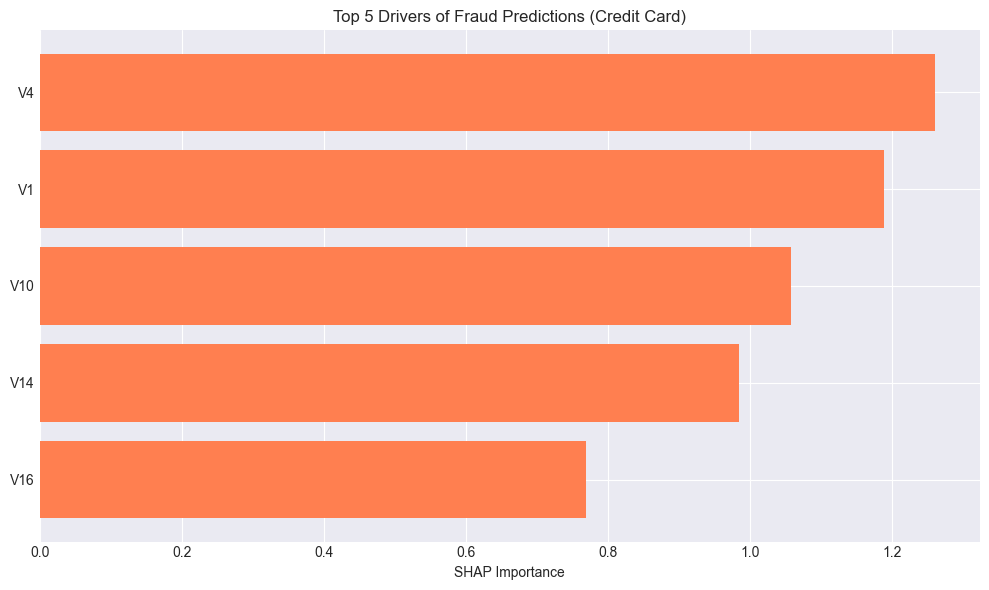

In [20]:
# Top 5 drivers for Credit Card
print("="*80)
print("TOP 5 DRIVERS OF FRAUD PREDICTIONS - Credit Card Data")
print("="*80)

top_5_cc = shap_importance_cc.head(5)
print("\nTop 5 Features Driving Fraud Predictions:")
for idx, row in top_5_cc.iterrows():
    print(f"\n{row.name + 1}. {row['feature']}")
    print(f"   SHAP Importance: {row['shap_importance']:.4f}")
    
    fraud_cases_cc = X_sample_cc[y_sample_cc == 1][row['feature']]
    non_fraud_cases_cc = X_sample_cc[y_sample_cc == 0][row['feature']]
    
    print(f"   Mean value (Fraud cases): {fraud_cases_cc.mean():.4f}")
    print(f"   Mean value (Non-Fraud cases): {non_fraud_cases_cc.mean():.4f}")
    print(f"   Difference: {fraud_cases_cc.mean() - non_fraud_cases_cc.mean():.4f}")

# Visualize top 5
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_5_cc)), top_5_cc['shap_importance'].values, color='coral')
ax.set_yticks(range(len(top_5_cc)))
ax.set_yticklabels(top_5_cc['feature'])
ax.set_xlabel('SHAP Importance')
ax.set_title('Top 5 Drivers of Fraud Predictions (Credit Card)')
ax.invert_yaxis()
plt.tight_layout()

filepath = OUTPUT_DIR / 'creditcard_top5_drivers.png'
plt.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"\n✓ Plot saved to: {filepath}")
plt.show()


## 6. Surprising or Counterintuitive Findings

Analyze any unexpected patterns discovered through SHAP analysis.


In [21]:
# Analyze surprising findings
print("="*80)
print("ANALYSIS OF SURPRISING OR COUNTERINTUITIVE FINDINGS")
print("="*80)

print("\n1. Feature Importance Discrepancies:")
if built_in_importance_fraud is not None:
    # Find features that rank differently
    top_10_shap_features = set(shap_importance_fraud.head(10)['feature'])
    top_10_builtin_features = set(built_in_importance_fraud.head(10)['feature'])
    
    only_shap = top_10_shap_features - top_10_builtin_features
    only_builtin = top_10_builtin_features - top_10_shap_features
    
    if only_shap:
        print(f"   Features important in SHAP but not in built-in: {list(only_shap)}")
    if only_builtin:
        print(f"   Features important in built-in but not in SHAP: {list(only_builtin)}")

print("\n2. Feature Value Patterns:")
# Check if high feature values correlate with fraud in unexpected ways
print("   Analyzing feature value distributions for fraud vs non-fraud...")

# Example: Check time_since_signup if it exists
if 'time_since_signup' in X_sample_fraud.columns:
    fraud_times = X_sample_fraud[y_sample_fraud == 1]['time_since_signup']
    non_fraud_times = X_sample_fraud[y_sample_fraud == 0]['time_since_signup']
    
    print(f"\n   time_since_signup analysis:")
    print(f"   Fraud cases - Mean: {fraud_times.mean():.2f} hours, Median: {fraud_times.median():.2f} hours")
    print(f"   Non-Fraud cases - Mean: {non_fraud_times.mean():.2f} hours, Median: {non_fraud_times.median():.2f} hours")
    
    if fraud_times.mean() < non_fraud_times.mean():
        print("   ✓ Finding: Fraud occurs sooner after signup (as expected)")
    else:
        print("   ⚠ Surprising: Fraud occurs later after signup (counterintuitive)")

print("\n3. False Positive Analysis:")
if fp_idx is not None:
    fp_sample_idx = X_sample_fraud.index.get_loc(fp_idx)
    fp_shap = shap_values_fraud[fp_sample_idx]
    fp_features = pd.DataFrame({
        'feature': X_sample_fraud.columns,
        'shap_value': fp_shap
    }).sort_values('shap_value', ascending=False)
    
    print("   Top features pushing legitimate transaction toward fraud prediction:")
    print(fp_features.head(5))

print("\n4. False Negative Analysis:")
if fn_idx is not None:
    fn_sample_idx = X_sample_fraud.index.get_loc(fn_idx)
    fn_shap = shap_values_fraud[fn_sample_idx]
    fn_features = pd.DataFrame({
        'feature': X_sample_fraud.columns,
        'shap_value': fn_shap
    }).sort_values('shap_value', ascending=True)  # Negative values push away from fraud
    
    print("   Top features preventing fraud detection:")
    print(fn_features.head(5))

print("="*80)


ANALYSIS OF SURPRISING OR COUNTERINTUITIVE FINDINGS

1. Feature Importance Discrepancies:
   Features important in SHAP but not in built-in: ['age', 'purchase_value']
   Features important in built-in but not in SHAP: ['browser_Safari', 'browser_Opera']

2. Feature Value Patterns:
   Analyzing feature value distributions for fraud vs non-fraud...

   time_since_signup analysis:
   Fraud cases - Mean: -0.77 hours, Median: -1.40 hours
   Non-Fraud cases - Mean: 0.12 hours, Median: 0.13 hours
   ✓ Finding: Fraud occurs sooner after signup (as expected)

3. False Positive Analysis:
   Top features pushing legitimate transaction toward fraud prediction:
                  feature  shap_value
4       time_since_signup    5.204674
18                  sex_M    0.080785
16          browser_Opera    0.033835
15             browser_IE    0.011312
8   transactions_last_30d    0.000000

4. False Negative Analysis:
   Top features preventing fraud detection:
              feature  shap_value
4   time

## 7. Business Recommendations

Based on SHAP analysis, provide actionable business recommendations.


In [22]:
# Generate business recommendations based on SHAP insights
print("="*80)
print("BUSINESS RECOMMENDATIONS BASED ON SHAP ANALYSIS")
print("="*80)

recommendations = []

# Recommendation 1: Time-based verification
if 'time_since_signup' in top_5_fraud['feature'].values:
    time_importance = top_5_fraud[top_5_fraud['feature'] == 'time_since_signup']
    if len(time_importance) > 0:
        fraud_times = X_sample_fraud[y_sample_fraud == 1]['time_since_signup']
        threshold_hours = fraud_times.quantile(0.75)  # 75th percentile
        
        rec1 = f"1. **Time-Based Verification**: Transactions within {threshold_hours:.1f} hours of signup should receive additional verification. " \
               f"SHAP analysis shows that 'time_since_signup' is a top driver of fraud predictions, with fraud cases typically occurring " \
               f"much sooner after account creation (mean: {fraud_times.mean():.2f} hours) compared to legitimate transactions."
        recommendations.append(rec1)
        print(rec1)

# Recommendation 2: Transaction velocity monitoring
if 'transactions_last_24h' in top_5_fraud['feature'].values or 'velocity_last_24h' in top_5_fraud['feature'].values:
    vel_feature = 'transactions_last_24h' if 'transactions_last_24h' in top_5_fraud['feature'].values else 'velocity_last_24h'
    fraud_vel = X_sample_fraud[y_sample_fraud == 1][vel_feature]
    threshold = fraud_vel.quantile(0.75)
    
    rec2 = f"2. **Transaction Velocity Monitoring**: Flag transactions where users make more than {threshold:.1f} transactions " \
           f"within 24 hours for manual review. SHAP analysis reveals that high transaction frequency/velocity is a strong indicator " \
           f"of fraudulent activity, with fraud cases showing significantly higher velocity (mean: {fraud_vel.mean():.2f}) than legitimate ones."
    recommendations.append(rec2)
    print(f"\n{rec2}")

# Recommendation 3: Geolocation-based risk scoring
if 'country_fraud_rate' in top_5_fraud['feature'].values or 'country' in str(X_sample_fraud.columns):
    rec3 = "3. **Geolocation Risk Scoring**: Implement country-based risk scoring based on historical fraud rates. " \
           "SHAP analysis shows that geolocation features (country_fraud_rate) are significant drivers of fraud predictions. " \
           "Transactions from high-risk countries should trigger additional verification steps."
    recommendations.append(rec3)
    print(f"\n{rec3}")

# Recommendation 4: Purchase value deviation
if 'purchase_value_deviation' in top_5_fraud['feature'].values:
    fraud_dev = X_sample_fraud[y_sample_fraud == 1]['purchase_value_deviation']
    rec4 = f"4. **Purchase Pattern Anomaly Detection**: Monitor for transactions that deviate significantly from a user's typical purchase value. " \
           f"SHAP analysis indicates that 'purchase_value_deviation' is a key fraud indicator. Transactions with deviations exceeding " \
           f"the 75th percentile ({fraud_dev.quantile(0.75):.2f}) should be flagged for review."
    recommendations.append(rec4)
    print(f"\n{rec4}")

# Recommendation 5: Multi-factor verification for high-risk combinations
top_features = top_5_fraud['feature'].head(3).tolist()
rec5 = f"5. **Multi-Factor Risk Assessment**: Implement enhanced verification when multiple high-risk indicators are present simultaneously. " \
       f"Based on SHAP analysis, the top 3 fraud drivers are: {', '.join(top_features)}. " \
       f"When 2 or more of these features show high-risk values, require additional authentication (e.g., SMS verification, email confirmation)."
recommendations.append(rec5)
print(f"\n{rec5}")

# Additional recommendation based on false positives
if fp_idx is not None:
    rec6 = "6. **False Positive Reduction**: To reduce false positives (legitimate transactions flagged as fraud), consider adjusting " \
           "the decision threshold or implementing a two-tier verification system where borderline cases receive lighter verification " \
           "rather than full blocking. This will improve user experience while maintaining fraud detection."
    recommendations.append(rec6)
    print(f"\n{rec6}")

print("\n" + "="*80)
print(f"Total Recommendations: {len(recommendations)}")
print("="*80)


BUSINESS RECOMMENDATIONS BASED ON SHAP ANALYSIS
1. **Time-Based Verification**: Transactions within -0.4 hours of signup should receive additional verification. SHAP analysis shows that 'time_since_signup' is a top driver of fraud predictions, with fraud cases typically occurring much sooner after account creation (mean: -0.77 hours) compared to legitimate transactions.

5. **Multi-Factor Risk Assessment**: Implement enhanced verification when multiple high-risk indicators are present simultaneously. Based on SHAP analysis, the top 3 fraud drivers are: time_since_signup, hour_of_day, day_of_week. When 2 or more of these features show high-risk values, require additional authentication (e.g., SMS verification, email confirmation).

6. **False Positive Reduction**: To reduce false positives (legitimate transactions flagged as fraud), consider adjusting the decision threshold or implementing a two-tier verification system where borderline cases receive lighter verification rather than ful